# Chapter 1. 비전 언어 모델 알아보기

## 1.3. 이미지 캡셔닝 실습

### 1.3.1. 실습 환경 준비

In [ ]:
from huggingface_hub import hf_hub_download

# 허깅페이스 Hub에서 이미지 파일 다운로드
filenames = ["Part-3/cat.jpg", "Part-3/astronaut.jpeg", "Part-3/logo.png"]
filepaths = [
   hf_hub_download(
       repo_id='woojun-jung/multimodal-guide-using-huggingface',
       repo_type="dataset",
       filename=name
   )
   for name in filenames
]

# (선택) 다운로드된 로컬 경로 확인
for p in filepaths:
    print(p)

Part-3/cat.jpg:   0%|          | 0.00/56.7k [00:00<?, ?B/s]

Part-3/astronaut.jpeg:   0%|          | 0.00/148k [00:00<?, ?B/s]

Part-3/logo.png:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--woojun-jung--multimodal-guide-using-huggingface/snapshots/e635e4548aa57c19cb3eea3c1ae554bc9489c608/Part-3/cat.jpg
/root/.cache/huggingface/hub/datasets--woojun-jung--multimodal-guide-using-huggingface/snapshots/e635e4548aa57c19cb3eea3c1ae554bc9489c608/Part-3/astronaut.jpeg
/root/.cache/huggingface/hub/datasets--woojun-jung--multimodal-guide-using-huggingface/snapshots/e635e4548aa57c19cb3eea3c1ae554bc9489c608/Part-3/logo.png


In [ ]:
from transformers.image_utils import load_images

cat_image, astronaut_image, logo_image = load_images(filepaths)

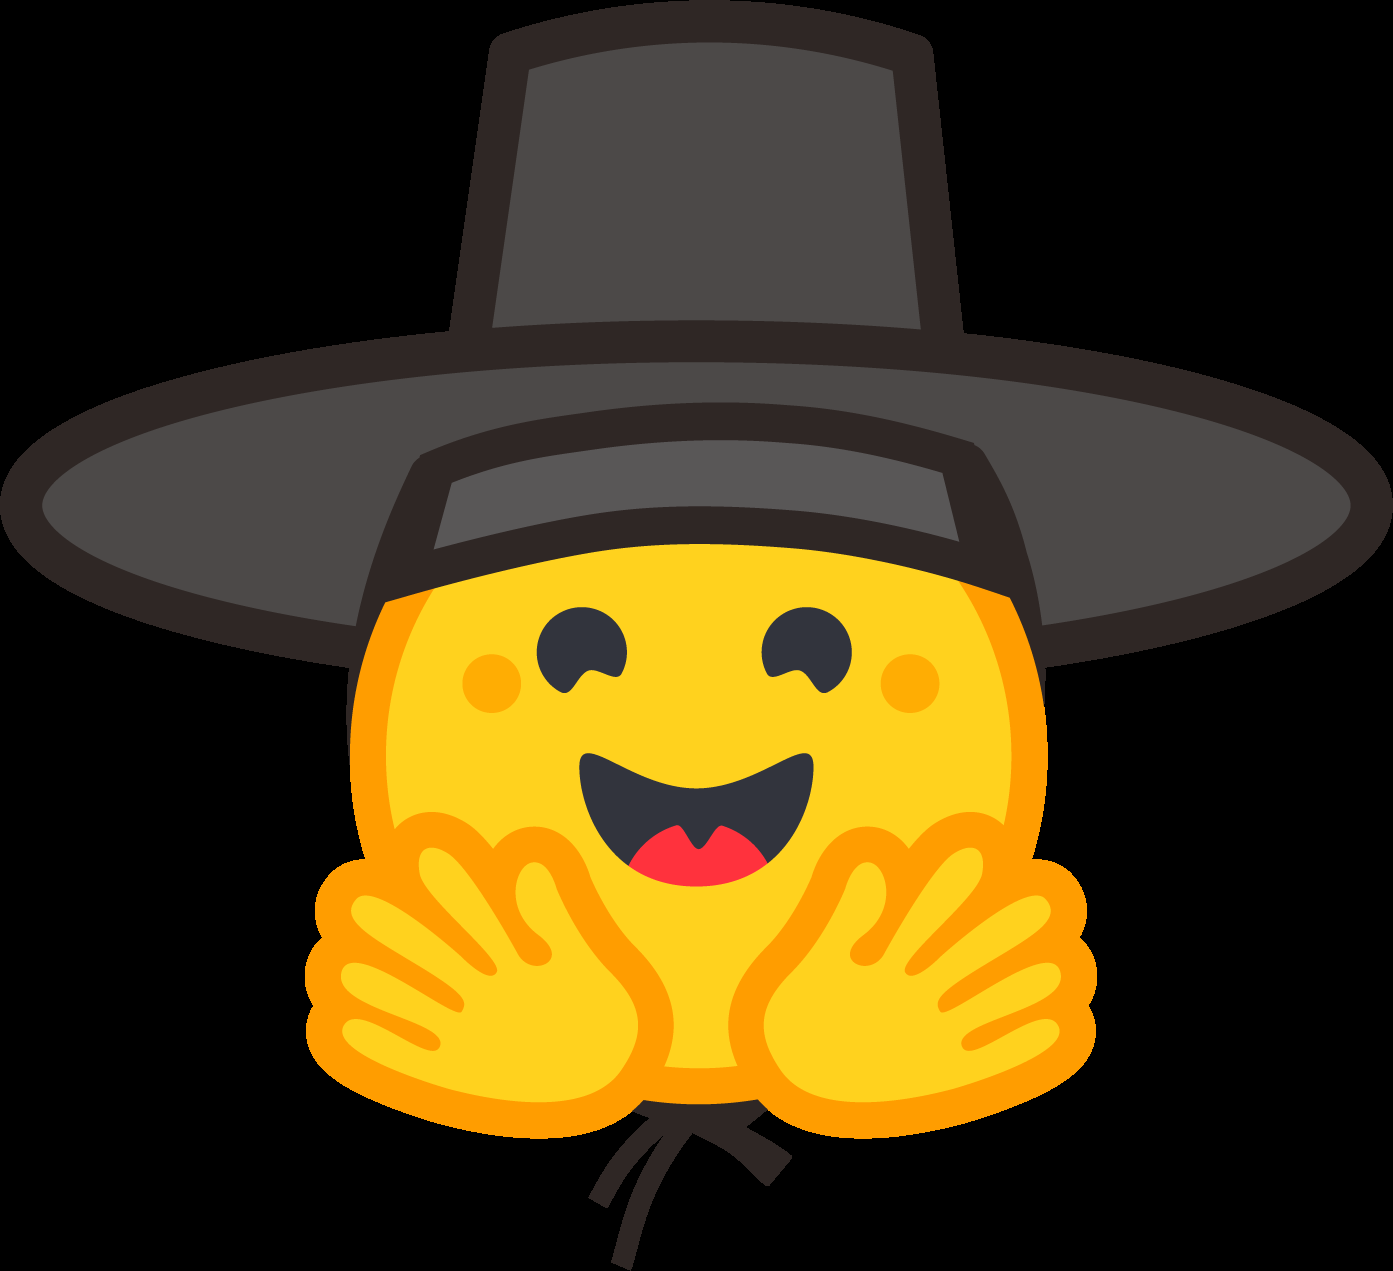

In [ ]:
from transformers.image_utils import load_image

# load_image: URL을 직접 입력할 수 있음
image = load_image("https://huggingface.co/datasets/huggingface-KREW/multimodal-book/resolve/main/Part-3/logo.png")
display(image)

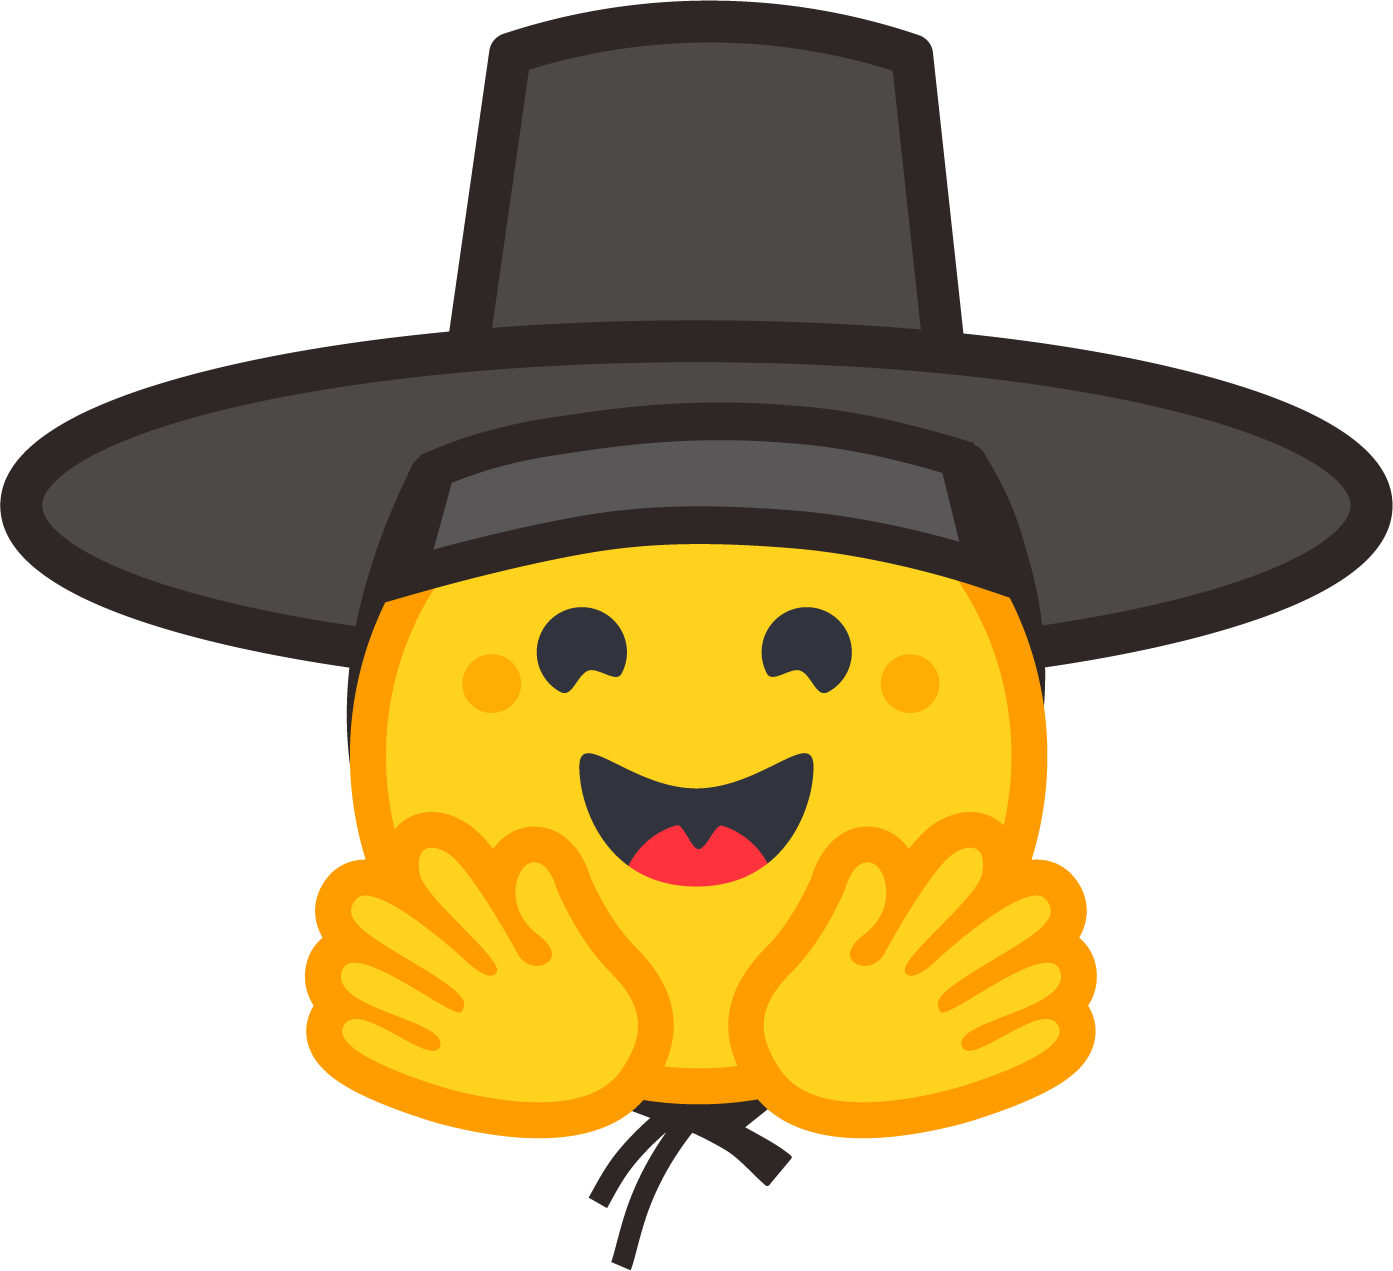

In [ ]:
# PIL의 경우: 추가 작업이 필요함
from PIL import Image
import requests
from io import BytesIO

response = requests.get("https://huggingface.co/datasets/huggingface-KREW/multimodal-book/resolve/main/Part-3/logo.png")
image = Image.open(BytesIO(response.content))
display(image)

### 1.3.3. BLIP-2로 이미지 캡셔닝하기

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText

blip2_model_id = "Salesforce/blip2-opt-2.7b"

blip2_processor = AutoProcessor.from_pretrained(blip2_model_id)

# GPU가 있으면 자동으로 활용하도록 로드
blip2_model = AutoModelForImageTextToText.from_pretrained(
    blip2_model_id,
    device_map="auto",
)

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


In [ ]:
# 이미지를 모델 입력 형식으로 변환
inputs = blip2_processor(images=cat_image, return_tensors="pt").to(blip2_model.device)

# 캡션 생성
outputs = blip2_model.generate(**inputs, max_new_tokens=50)

# 생성된 토큰을 텍스트로 디코딩
caption = blip2_processor.decode(outputs[0], skip_special_tokens=True)

print("[BLIP-2] 고양이 이미지 캡션:", caption)

[BLIP-2] 고양이 이미지 캡션: a cat is sleeping on the hood of a car



### 1.3.4. LLaVA로 이미지 캡셔닝하기

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

# LLaVA 모델 로드
llava_model_id = "llava-hf/llava-1.5-7b-hf"
llava_processor = AutoProcessor.from_pretrained(llava_model_id)
llava_model = AutoModelForImageTextToText.from_pretrained(
   llava_model_id,
   torch_dtype=torch.float16,  # 가중치를 float16으로 로드해 메모리 절약
   device_map="auto"  # 자동 배치
)

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [ ]:
# LLaVA는 대화 형식의 프롬프트를 사용합니다
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe this image in one sentence."},
        ],
    },
]

# 대화 형식을 모델이 이해하는 프롬프트 문자열로 변환
prompt = llava_processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=False,
)

# 이미지와 프롬프트를 함께 입력
inputs = llava_processor(images=cat_image, text=prompt, return_tensors="pt").to(llava_model.device)

# 캡션 생성
outputs = llava_model.generate(**inputs, max_new_tokens=50)

# 생성된 텍스트 디코딩
caption = llava_processor.decode(outputs[0], skip_special_tokens=True).strip()

print("[LLaVA] 고양이 이미지 캡션:", caption)

[LLaVA] 고양이 이미지 캡션: USER:  
Describe this image in one sentence. ASSISTANT: A cat is sleeping on top of a red car.


In [ ]:
# "ASSISTANT:" 이후의 답변만 추출
answer = caption.split("ASSISTANT:", 1)[-1].strip()
print(answer)

A cat is sleeping on top of a red car.


### 1.3.5. 여러 이미지로 모델 비교하기

=== 우주비행사 이미지 캡셔닝 결과 ===


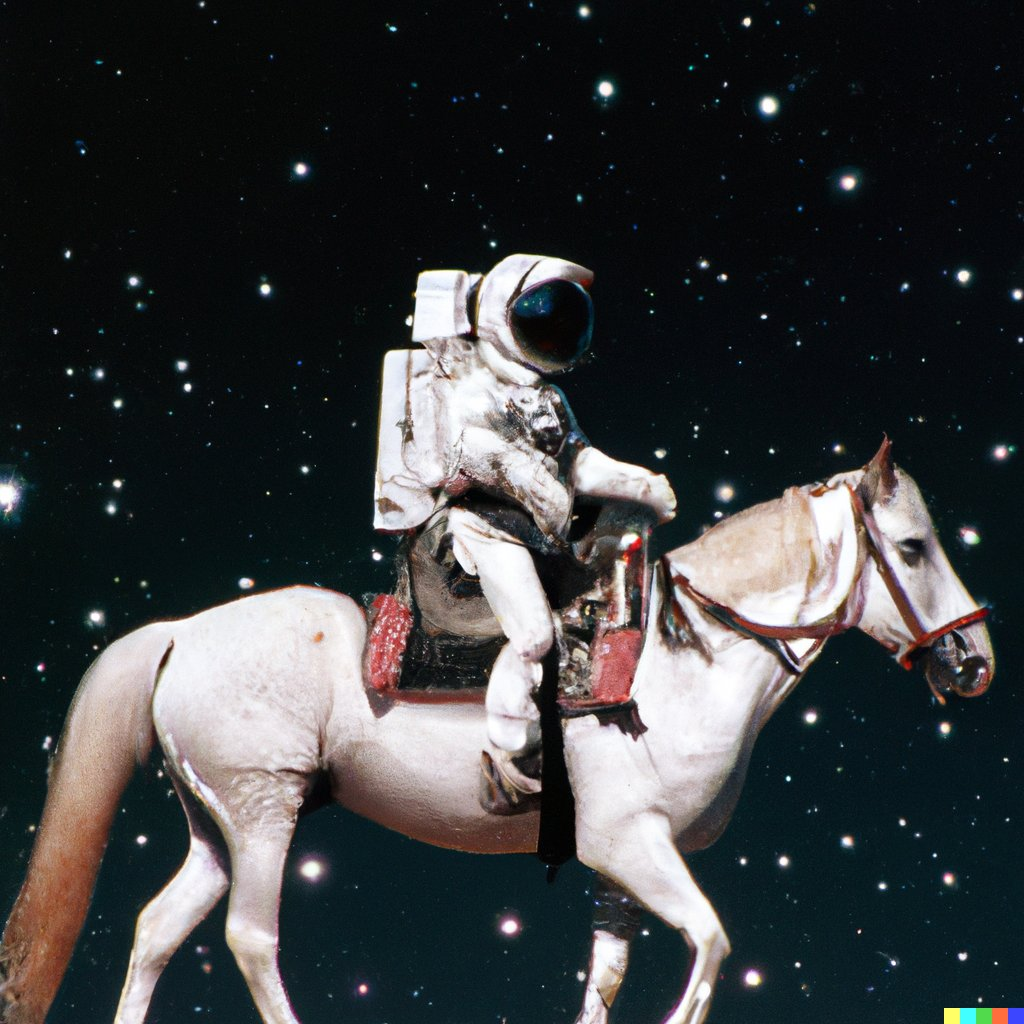

[BLIP-2] a white horse with a man in a spacesuit riding it
[LLaVA] A man in a space suit rides a white horse.

=== 로고 이미지 캡셔닝 결과 ===


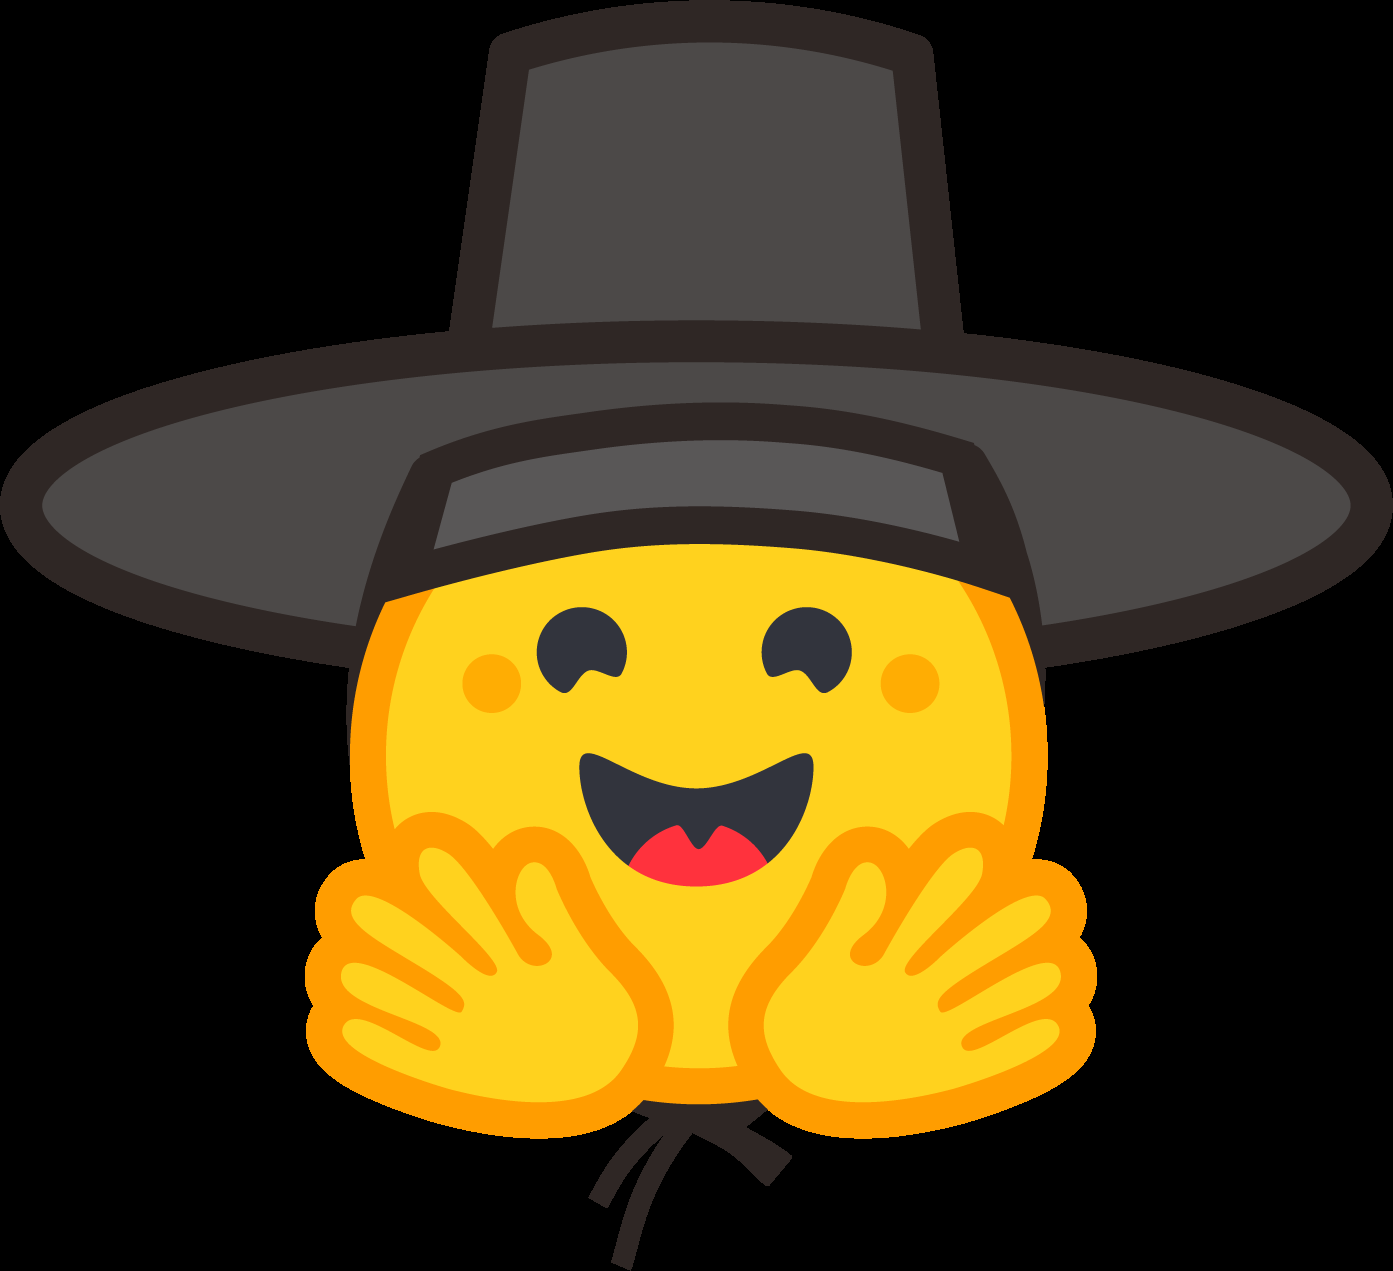

[BLIP-2] a yellow smiley face wearing a black hat
[LLaVA] A yellow smiley face with a black hat on.


In [ ]:
from IPython.display import display

# LLaVA 프롬프트(재사용)
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe this image in one sentence."},
        ],
    },
]
prompt = llava_processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=False,
)

def caption_with_blip2(image):
    inputs = blip2_processor(images=image, return_tensors="pt").to(blip2_model.device)
    outputs = blip2_model.generate(**inputs, max_new_tokens=50)
    return blip2_processor.decode(outputs[0], skip_special_tokens=True).strip()

def caption_with_llava(image):
    inputs = llava_processor(images=image, text=prompt, return_tensors="pt").to(llava_model.device)
    outputs = llava_model.generate(**inputs, max_new_tokens=50)
    full_text = llava_processor.decode(outputs[0], skip_special_tokens=True).strip()
    return full_text.split("ASSISTANT:", 1)[-1].strip()

# 우주비행사 이미지
blip2_caption = caption_with_blip2(astronaut_image)
llava_caption = caption_with_llava(astronaut_image)

print("=== 우주비행사 이미지 캡셔닝 결과 ===")
display(astronaut_image)
print(f"[BLIP-2] {blip2_caption}")
print(f"[LLaVA] {llava_caption}")

# 로고 이미지
blip2_caption = caption_with_blip2(logo_image)
llava_caption = caption_with_llava(logo_image)

print("\n=== 로고 이미지 캡셔닝 결과 ===")
display(logo_image)
print(f"[BLIP-2] {blip2_caption}")
print(f"[LLaVA] {llava_caption}")

### 1.3.6. 조건부 캡셔닝: 원하는 스타일로 설명 생성하기

In [ ]:
prompts = [
    "a photo of",
    "a man is",
    "there is"
]

for prompt in prompts:
    inputs = blip2_processor(images=astronaut_image, text=prompt, return_tensors="pt").to(blip2_model.device)
    outputs = blip2_model.generate(**inputs, max_new_tokens=50)
    caption = blip2_processor.decode(outputs[0], skip_special_tokens=True).strip()

    print(f"\n프롬프트: '{prompt}'")
    print(f"결과: {caption}")


프롬프트: 'a photo of'
결과: a photo of an astronaut riding a horse

프롬프트: 'a man is'
결과: a man is riding a horse in space

프롬프트: 'there is'
결과: there is a man in a spacesuit riding a horse


In [ ]:
instructions = [
    "Describe this image briefly in one sentence.",
    "Describe this image in detail, focusing on colors and textures.",
    "What is the main subject of this image?",
]

for instruction in instructions:
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": instruction},
            ],
        },
    ]

    prompt = llava_processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=False,
    )

    inputs = llava_processor(images=astronaut_image, text=prompt, return_tensors="pt").to(llava_model.device)

    # 샘플링을 끄면(=결정적으로 생성) 비교적 일관된 출력으로 비교하기 쉽습니다.
    outputs = llava_model.generate(**inputs, max_new_tokens=100, do_sample=False)

    full_output = llava_processor.decode(outputs[0], skip_special_tokens=True).strip()
    answer = full_output.split("ASSISTANT:", 1)[-1].strip()

    print(f"\n지시문: '{instruction}'")
    print(f"결과: {answer}")


지시문: 'Describe this image briefly in one sentence.'
결과: A man in a space suit rides a white horse.

지시문: 'Describe this image in detail, focusing on colors and textures.'
결과: The image features a white horse with a man dressed in a space suit riding on its back. The man appears to be a space traveler, and the horse is carrying him through the night sky. The scene is set against a backdrop of stars, creating a sense of adventure and exploration. The man's space suit is white, and the horse's fur is also white, which adds to the overall cohesion of the scene.

지시문: 'What is the main subject of this image?'
결과: The main subject of this image is a man dressed in a space suit riding a white horse.
